# Task 2

---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

### Exploratory data analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report

)

In [38]:
df = pd.read_csv(
    "customer_booking.csv",
    encoding="ISO-8859-1"
)

The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [40]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [41]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

In [42]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [43]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

In [44]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 50000
Number of columns: 14


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  int64  
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(9), object(4)
memory usage: 5.3+ 

In [46]:
#Check missing values
df.isnull().sum()

,0
num_passengers,0
sales_channel,0
trip_type,0
purchase_lead,0
length_of_stay,0
flight_hour,0
flight_day,0
route,0
booking_origin,0
wants_extra_baggage,0


In [47]:
#You can also calculate the percentage:

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

,0
num_passengers,0.0
sales_channel,0.0
trip_type,0.0
purchase_lead,0.0
length_of_stay,0.0
flight_hour,0.0
flight_day,0.0
route,0.0
booking_origin,0.0
wants_extra_baggage,0.0


In [48]:
#the target variable

#booking_complete is the target

df["booking_complete"].value_counts()

,count
booking_complete,
0,42522
1,7478


In [49]:
#percentage
df["booking_complete"].value_counts(normalize=True) * 100

,proportion
booking_complete,
0,85.044
1,14.956


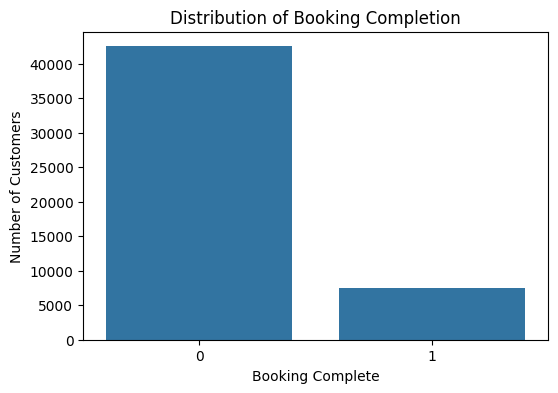

In [50]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="booking_complete"
)

plt.title("Distribution of Booking Completion")
plt.xlabel("Booking Complete")
plt.ylabel("Number of Customers")

plt.show()

Why this matters

You will probably find that 0 is much more common than 1.

This means the dataset is imbalanced.

That's important when evaluating the model because accuracy alone may be misleading.

For example, if 85% of customers didn't complete a booking, a model that predicted 0 for everyone would already achieve 85% accuracy while being completely useless for finding potential bookers.

Therefore, later we will look at:

Accuracy
Precision
Recall
F1-score
ROC-AUC

In [51]:
#Step 4 — Explore categorical variables

#Let's identify the categorical columns.

categorical_columns = df.select_dtypes(
    include=["object"]
).columns

print(categorical_columns)

Index(['sales_channel', 'trip_type', 'route', 'booking_origin'], dtype='object')


In [52]:
for column in categorical_columns:
    print(
        column,
        "→",
        df[column].nunique(),
        "unique values"
    )

sales_channel → 2 unique values
trip_type → 3 unique values
route → 799 unique values
booking_origin → 104 unique values


In [53]:
#Explore numerical variables
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print(numeric_columns)

Index(['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour',
       'flight_day', 'wants_extra_baggage', 'wants_preferred_seat',
       'wants_in_flight_meals', 'flight_duration', 'booking_complete'],
      dtype='object')


In [54]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
num_passengers,50000.0,1.591240,1.020165,1.00,1.00,1.00,2.00,9.0
purchase_lead,50000.0,84.940480,90.451378,0.00,21.00,51.00,115.00,867.0
length_of_stay,50000.0,23.044560,33.887670,0.00,5.00,17.00,28.00,778.0
flight_hour,50000.0,9.066340,5.412660,0.00,5.00,9.00,13.00,23.0
flight_day,50000.0,3.814420,1.992792,1.00,2.00,4.00,5.00,7.0
wants_extra_baggage,50000.0,0.668780,0.470657,0.00,0.00,1.00,1.00,1.0
wants_preferred_seat,50000.0,0.296960,0.456923,0.00,0.00,0.00,1.00,1.0
wants_in_flight_meals,50000.0,0.427140,0.494668,0.00,0.00,0.00,1.00,1.0
flight_duration,50000.0,7.277561,1.496863,4.67,5.62,7.57,8.83,9.5
booking_complete,50000.0,0.149560,0.356643,0.00,0.00,0.00,0.00,1.0


**Convert flight_day**

In [55]:
day_mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7
}

df["flight_day"] = df["flight_day"].map(day_mapping)

In [56]:
df["flight_day"].unique()

array([nan])

In [57]:
df["flight_day"].value_counts()

,count
flight_day,


In [58]:
df = pd.read_csv(
    "customer_booking.csv",
    encoding="ISO-8859-1"
)

In [59]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [60]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [61]:
booking_by_channel = (
    df.groupby("sales_channel")["booking_complete"]
      .mean()
      .sort_values(ascending=False)
)

print(booking_by_channel)

sales_channel
Internet    0.154770
Mobile      0.108402
Name: booking_complete, dtype: float64


In [62]:
booking_by_channel * 100

,booking_complete
sales_channel,
Internet,15.476995
Mobile,10.840157


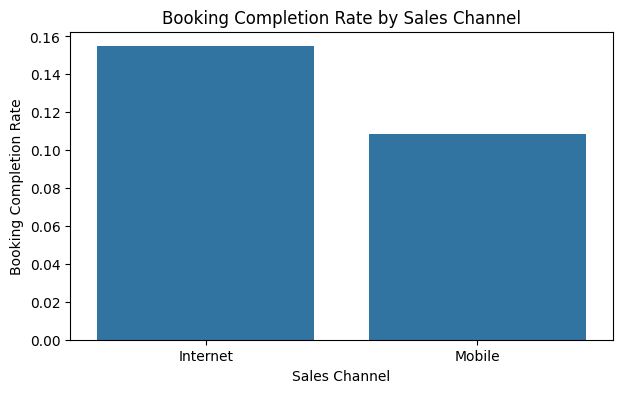

In [63]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=booking_by_channel.index,
    y=booking_by_channel.values
)

plt.title("Booking Completion Rate by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Booking Completion Rate")

plt.show()

In [64]:
booking_by_trip = (
    df.groupby("trip_type")["booking_complete"]
      .mean()
      .sort_values(ascending=False)
)

print(booking_by_trip * 100)

trip_type
RoundTrip     15.057478
OneWay         5.167959
CircleTrip     4.310345
Name: booking_complete, dtype: float64


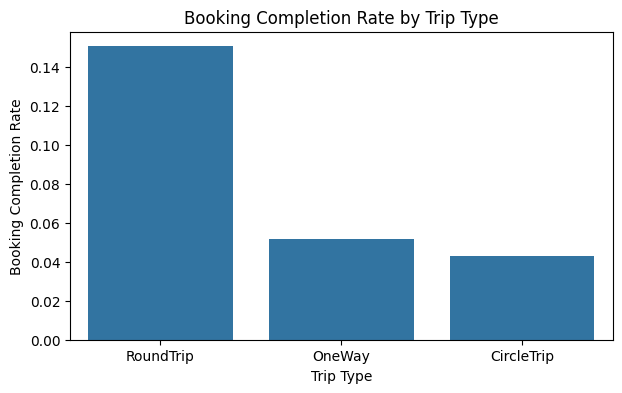

In [65]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=booking_by_trip.index,
    y=booking_by_trip.values
)

plt.title("Booking Completion Rate by Trip Type")
plt.xlabel("Trip Type")
plt.ylabel("Booking Completion Rate")

plt.show()

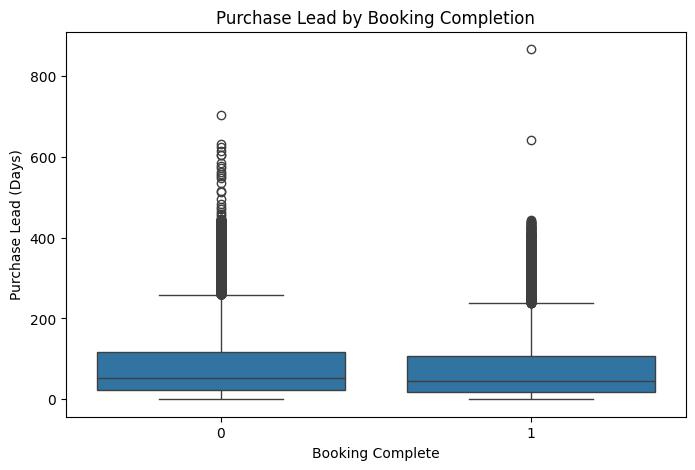

In [67]:
#Check purchase lead

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="booking_complete",
    y="purchase_lead"
)

plt.title("Purchase Lead by Booking Completion")
plt.xlabel("Booking Complete")
plt.ylabel("Purchase Lead (Days)")

plt.show()

In [69]:
df.groupby("booking_complete")["purchase_lead"].mean()

,purchase_lead
booking_complete,
0,85.779926
1,80.167157


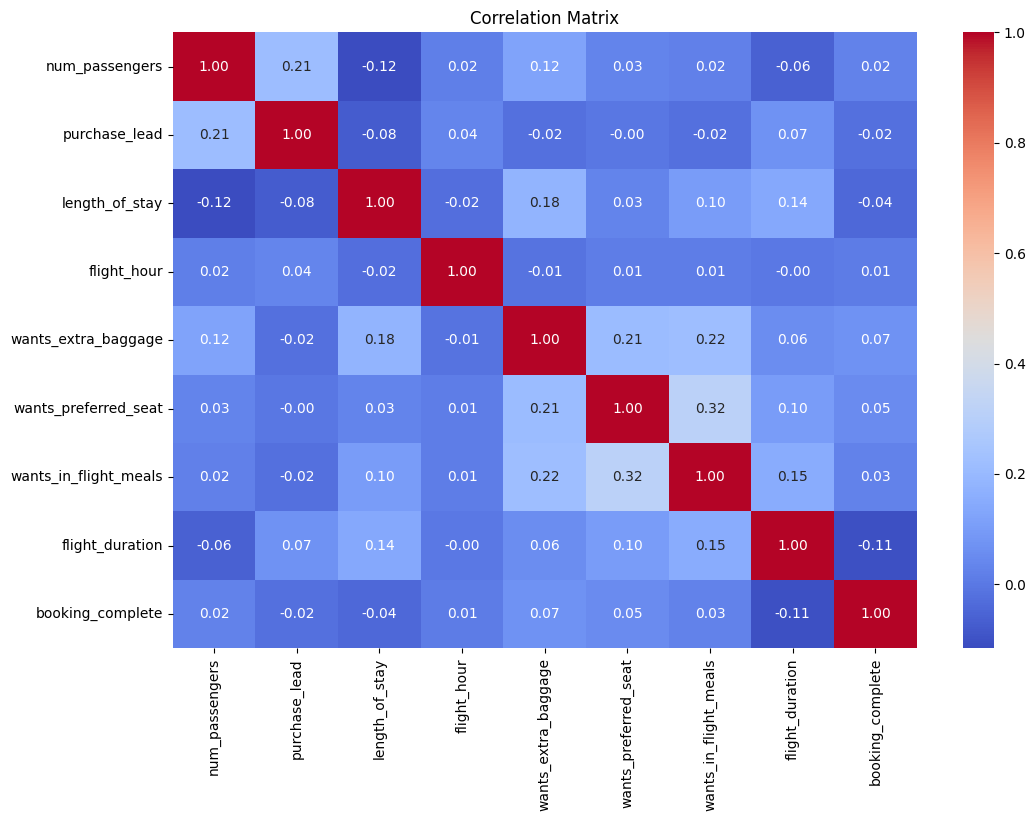

In [70]:
#Check numerical correlations

plt.figure(figsize=(12, 8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

This gives you an initial idea of which numerical variables have relationships with the target.

Important: correlation is not the same as predictive importance. Later, the Random Forest will give us a better measure of feature importance.

# Step 11 — Feature engineering
This is where we can improve the dataset before modelling.

A useful feature is whether the flight occurs on a weekend.

Because we converted flight_day:

In [71]:
df["is_weekend"] = df["flight_day"].isin([6, 7]).astype(int)

In [72]:
df[["flight_day", "is_weekend"]].head()

,flight_day,is_weekend
0,Sat,0
1,Sat,0
2,Wed,0
3,Sat,0
4,Wed,0


Another useful feature: total additional services

We have:

extra baggage
preferred seat
in-flight meals

We can combine these into one feature:

In [73]:
df["total_extra_services"] = (
    df["wants_extra_baggage"]
    + df["wants_preferred_seat"]
    + df["wants_in_flight_meals"]
)

In [74]:
df["total_extra_services"].value_counts().sort_index()

,count
total_extra_services,
0,10455
1,18216
2,12559
3,8770


# Step 12 — Check for duplicates

In [75]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 719


In [76]:
df = df.drop_duplicates().copy()

In [77]:
print(df.shape)

(49281, 16)


# Step 13 — Prepare X and y

X = predictor variables

y = target variable

In [78]:
X = df.drop("booking_complete", axis=1)

y = df["booking_complete"]

In [79]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (49281, 15)
y shape: (49281,)


# Step 14 — Identify categorical and numerical features

Because Random Forest cannot directly work with text such as "Internet" or "Australia", we'll encode categorical variables.

In [80]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin']

Numerical features:
['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour', 'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals', 'flight_duration', 'is_weekend', 'total_extra_services']


# Step 15 — Train/test split

We'll reserve 20% of the data for final testing.

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Why stratify=y?

Because our target is imbalanced.

stratify=y ensures that the train and test sets have approximately the same proportion of:

completed bookings
non-completed bookings

# Step 16 — Encode categorical variables

We'll use OneHotEncoder.

In [83]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

#Step 17 — Build the Random Forest model

Now we'll create the Random Forest.

In [95]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

In [96]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf_model)
    ]
)

#Step 18 — Train the model

In [97]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sales_channel', 'trip_type',
                                                   'flight_day', 'route',
                                                   'booking_origin']),
                                                 ('numerical', 'passthrough',
                                                  ['num_passengers',
                                                   'purchase_lead',
                                                   'length_of_stay',
                                                   'flight_hour',
                                                   'wants_extra_baggage',
                                                   'wants_preferred_seat',
                                                   'wants_in_flight_meals',
                                                   'flight_duration',
                                                   'is_weekend',
                                                   'total_extra_services'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

#Step 19 — Make predictions

In [88]:
y_pred = model.predict(X_test)

y_probability = model.predict_proba(X_test)[:, 1]

#Step 20 — Evaluate the model

Start with accuracy:

In [98]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.848635487470833


In [99]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.848635487470833
Precision: 0.480225988700565
Recall   : 0.11502029769959404
F1 Score : 0.185589519650655
ROC-AUC  : 0.7694158878089612


In [100]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      8379
           1       0.48      0.12      0.19      1478

    accuracy                           0.85      9857
   macro avg       0.67      0.55      0.55      9857
weighted avg       0.81      0.85      0.81      9857



#Step 21 — Confusion matrix

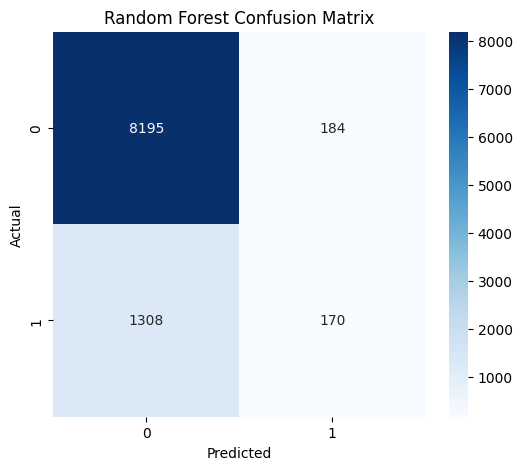

In [101]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

This lets you explain:

True Positive → customer actually booked and model predicted booking
True Negative → customer didn't book and model predicted no booking
False Positive → model predicted booking but customer didn't book
False Negative → customer booked but model missed them

For the business problem, false negatives are particularly interesting, because these are customers who actually booked but the model failed to identify them.

#Step 22 — Cross-validation

The task specifically asks for cross-validation.

We'll use 5-fold stratified cross-validation.

In [102]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [103]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [104]:
for metric in scoring.keys():
    scores = cv_results[f"test_{metric}"]

    print(
        f"{metric.upper():10} "
        f"Mean: {scores.mean():.4f} "
        f"Std: {scores.std():.4f}"
    )

ACCURACY   Mean: 0.8482 Std: 0.0010
PRECISION  Mean: 0.4734 Std: 0.0164
RECALL     Mean: 0.1099 Std: 0.0109
F1         Mean: 0.1782 Std: 0.0155
ROC_AUC    Mean: 0.7739 Std: 0.0027


#Step 23 — Feature importance

Now comes one of the most important parts of the task.

The Random Forest allows us to determine which variables contributed most to predictions.

First retrieve the encoded feature names:

In [105]:
feature_names = (
    model.named_steps["preprocessor"]
    .get_feature_names_out()
)

In [106]:
importance = (
    model.named_steps["classifier"]
    .feature_importances_
)

In [107]:
#create data frame

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})

In [108]:
feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
894,numerical__purchase_lead,0.117010
895,numerical__length_of_stay,0.099149
896,numerical__flight_hour,0.096257
802,categorical__booking_origin_Australia,0.049471
900,numerical__flight_duration,0.043479
893,numerical__num_passengers,0.039255
844,categorical__booking_origin_Malaysia,0.039165
902,numerical__total_extra_services,0.024376
6,categorical__flight_day_Mon,0.013756
10,categorical__flight_day_Tue,0.013305


#Step 24 — Visualize feature importance

main visualizations for the task.

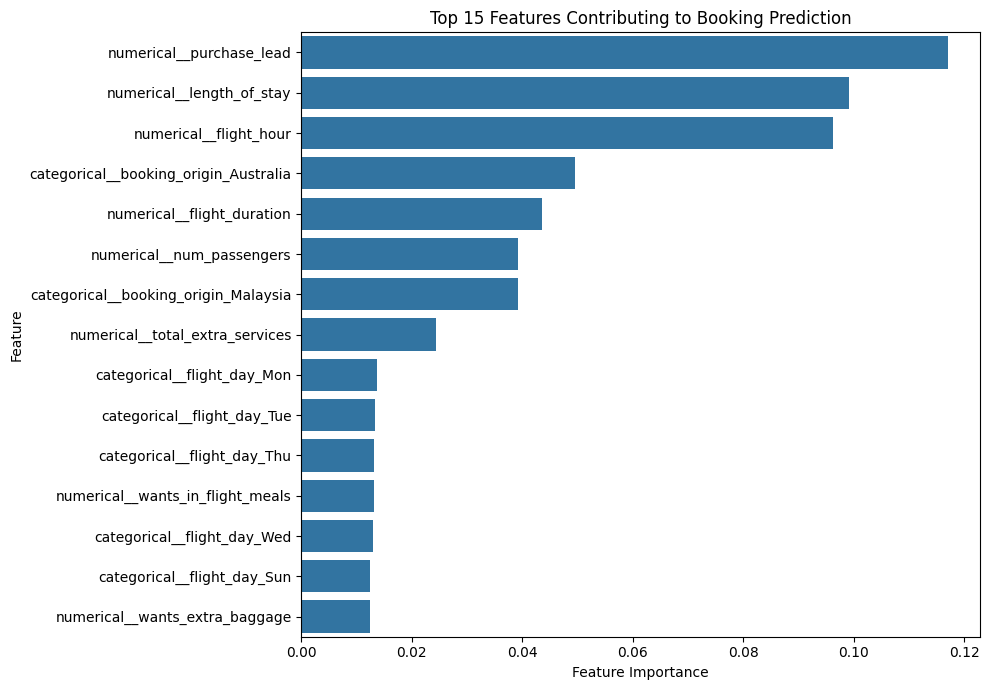

In [109]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top 15 Features Contributing to Booking Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

#Step 25 — Make the feature names easier to understand

Because one-hot encoding creates names such as:

categorical__route_AKLDEL

categorical__booking_origin_Australia

In [110]:
feature_importance["feature_clean"] = (
    feature_importance["feature"]
    .str.replace("categorical__", "", regex=False)
    .str.replace("numerical__", "", regex=False)
)

In [111]:
feature_importance[
    ["feature_clean", "importance"]
].head(15)

,feature_clean,importance
894,purchase_lead,0.117010
895,length_of_stay,0.099149
896,flight_hour,0.096257
802,booking_origin_Australia,0.049471
900,flight_duration,0.043479
893,num_passengers,0.039255
844,booking_origin_Malaysia,0.039165
902,total_extra_services,0.024376
6,flight_day_Mon,0.013756
10,flight_day_Tue,0.013305


#Step 26 — Save your feature importance

This is useful if you want to use the values in your PowerPoint.

In [112]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)